# Section 1 — Dataset Exploration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, GlobalAveragePooling2D
)
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import tensorflow as tf

gpu_list = tf.config.list_physical_devices("GPU")

if gpu_list:
    try:
        for device in gpu_list:
            tf.config.experimental.set_memory_growth(device, True)
        print("Dynamic memory growth activated")
    except RuntimeError as err:
        print(err)

print("GPU detected:", len(gpu_list) > 0)
print("GPU device list:", gpu_list)


Dynamic memory growth activated
GPU detected: True
GPU device list: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Loading

In [4]:
dataset_root = Path("/content/drive/MyDrive/Machine_Learning/Dataset/EuroSAT_RGB")
category_names = sorted(os.listdir(dataset_root))  # category names derived from folder names
print(f"Detected {len(category_names)} categories:", category_names)


Detected 10 categories: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### Sample Image Display

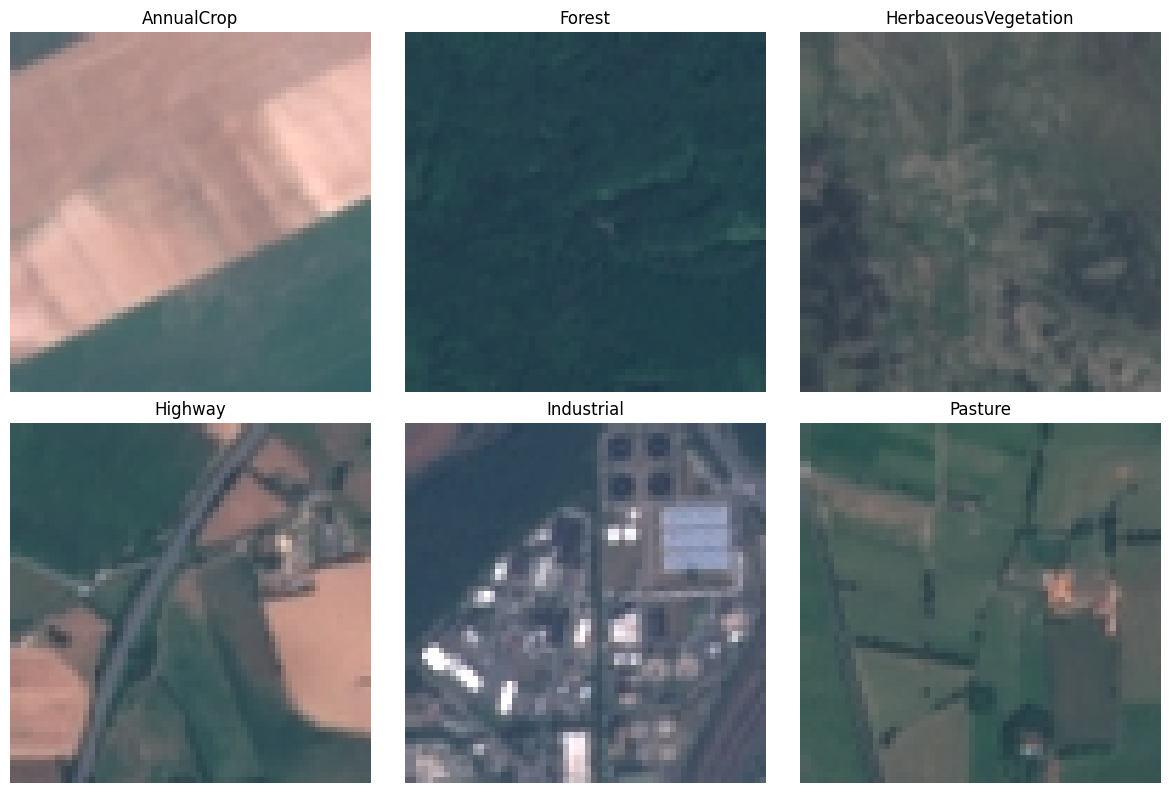

In [5]:
plt.figure(figsize=(12, 8))

for idx, cat in enumerate(category_names[:6]):
    cat_dir = os.path.join(dataset_root, cat)
    fname = os.listdir(cat_dir)[0]
    fpath = os.path.join(cat_dir, fname)

    sample_img = Image.open(fpath)

    plt.subplot(2, 3, idx + 1)
    plt.imshow(sample_img)
    plt.title(cat)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Image Count per Category

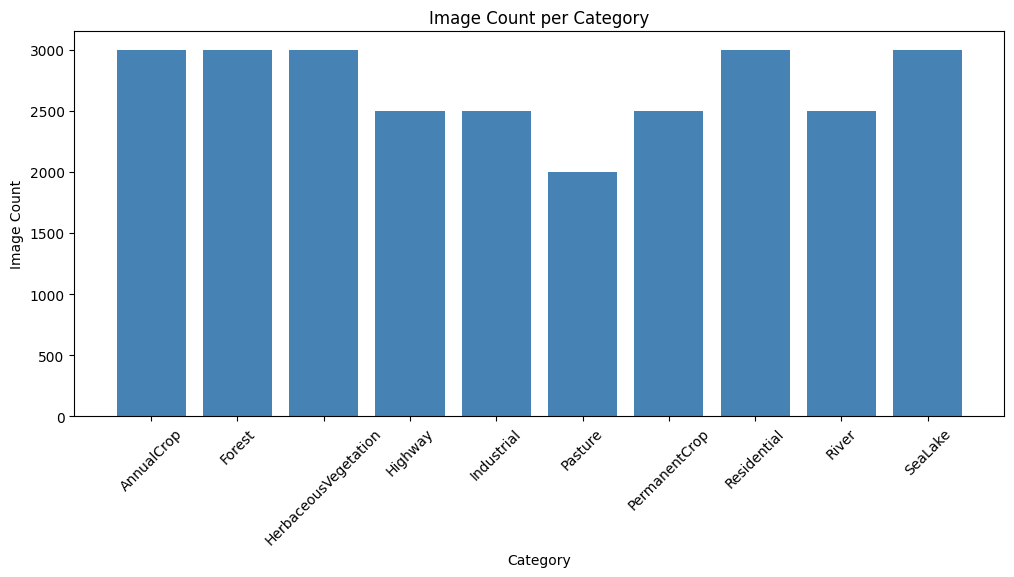

In [6]:
img_counts = []

for cat in category_names:
    cat_dir = os.path.join(dataset_root, cat)
    img_counts.append(len(os.listdir(cat_dir)))

plt.figure(figsize=(12, 5))
plt.bar(category_names, img_counts, color='steelblue')
plt.xticks(rotation=45)
plt.title("Image Count per Category")
plt.xlabel("Category")
plt.ylabel("Image Count")
plt.show()


### Base Data Generators

In [7]:
input_height = 128
input_width = 128
mini_batch = 128  # mini-batch gradient descent: processes 128 images per step

base_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,  # normalize pixel values from 0-255 to 0-1
    validation_split=0.2  # reserve 20% of data for validation
)


### Train and Validation Splits

In [8]:
training_set = base_datagen.flow_from_directory(
    dataset_root,  # root dataset path
    target_size=(input_height, input_width),  # resize all images to 128x128
    batch_size=mini_batch,
    class_mode='categorical',  # labels encoded as one-hot vectors
    subset='training',  # use the training portion
    shuffle=True  # shuffle to prevent order-based learning
)

validation_set = base_datagen.flow_from_directory(
    dataset_root,  # same root as training
    target_size=(input_height, input_width),  # consistent size with training
    batch_size=mini_batch,
    class_mode='categorical',  # labels encoded as one-hot vectors
    subset='validation',  # use the 20% held-out split
    shuffle=False  # no shuffle -- preserves evaluation order
)


Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


### Category Index Mapping

In [9]:
print("Category index mapping:")
print(training_set.class_indices)  # each folder is mapped to an integer label


Category index mapping:
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


### Training Batch Visualization

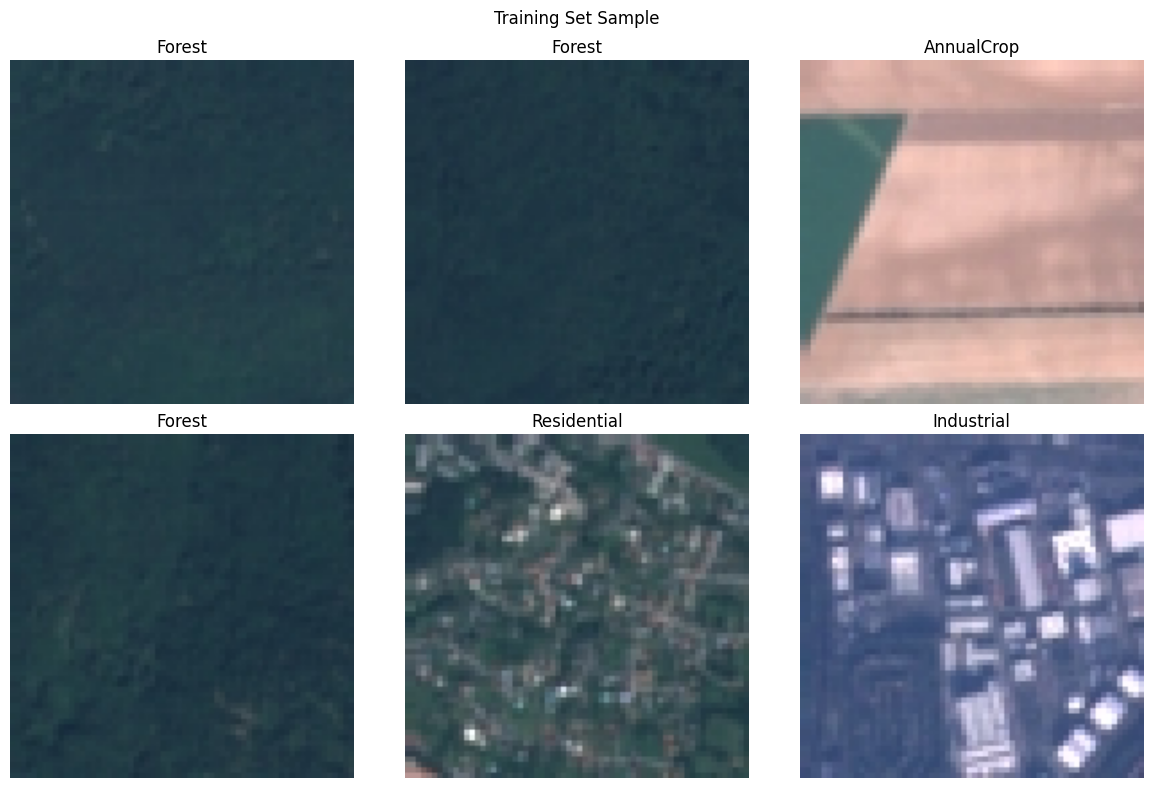

In [10]:
def display_batch(gen, cats, title="Batch Preview"):
    batch_imgs, batch_lbls = next(gen)  # fetch one batch from the generator
    plt.figure(figsize=(12, 8))
    for n in range(6):
        plt.subplot(2, 3, n + 1)
        plt.imshow(batch_imgs[n])
        plt.title(cats[np.argmax(batch_lbls[n])])  # convert one-hot back to category name
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

display_batch(training_set, category_names, "Training Set Sample")


### Data Augmentation Pipeline

In [11]:
aug_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=45,           # top-down satellite images are rotation-invariant
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,          # valid for aerial/satellite imagery
    shear_range=10,              # mild geometric distortion for robustness
    brightness_range=[0.8, 1.2]  # simulate varying lighting and atmospheric conditions
)

aug_training_set = aug_datagen.flow_from_directory(
    dataset_root,
    target_size=(input_height, input_width),
    batch_size=mini_batch,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

aug_validation_set = aug_datagen.flow_from_directory(
    dataset_root,
    target_size=(input_height, input_width),
    batch_size=mini_batch,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


### Augmented Sample Preview

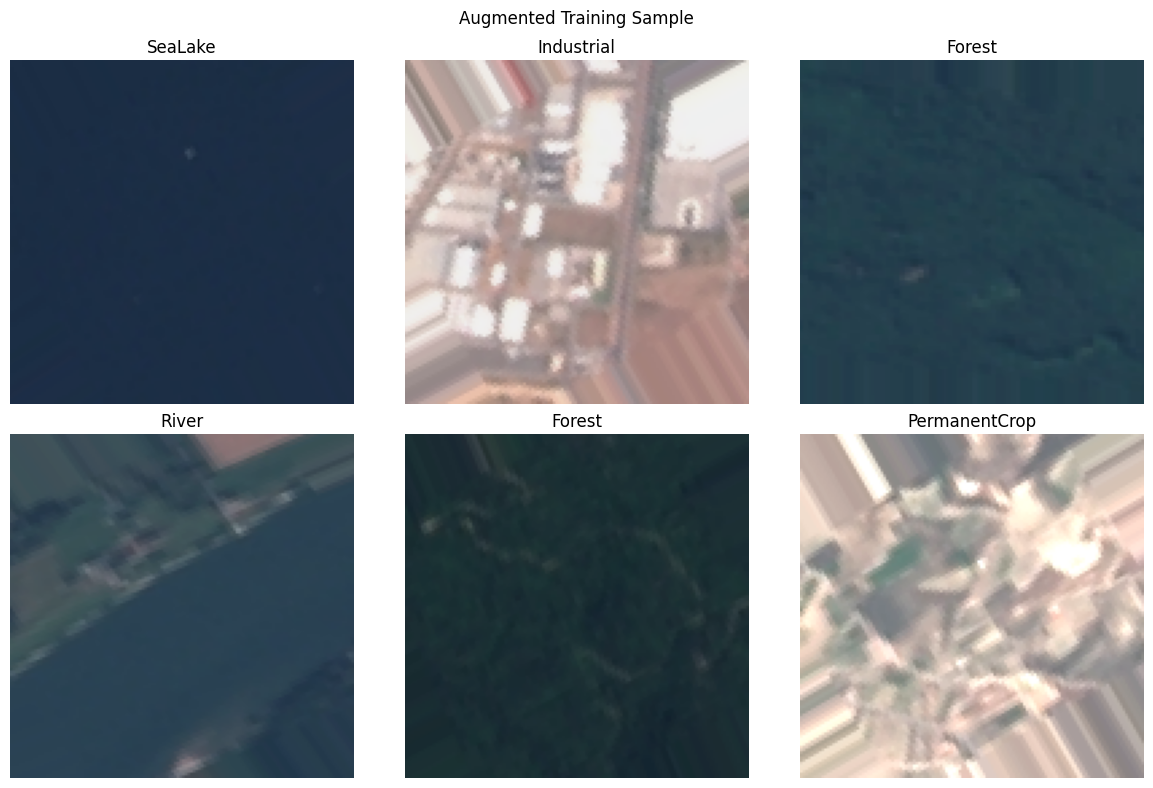

In [12]:
display_batch(aug_training_set, category_names, "Augmented Training Sample")


# Section 2 — Model Architecture

In [13]:
simple_cnn = Sequential([
    Input(shape=(input_height, input_width, 3)),  # explicit input layer -- avoids deprecation warning

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


### Advanced CNN (4 Blocks + Batch Normalisation)

In [14]:
deep_cnn = Sequential([
    Input(shape=(input_height, input_width, 3)),

    # Stage 1 -- 128x128 -> 64x64
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Stage 2 -- 64x64 -> 32x32
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Stage 3 -- 32x32 -> 16x16
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Stage 4 -- 16x16 -> 8x8  (with 128x128 input this yields 8x8 feature maps)
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    GlobalAveragePooling2D(),  # collapses each 8x8 feature map to a single value
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

deep_cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,138 (1.65 MB)

 Trainable params: 431,178 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

### Simple CNN Summary

In [15]:
simple_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,834 (25.02 MB)

 Trainable params: 6,557,834 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

### Transfer Learning — MobileNetV2 Backbone

In [16]:
# MobileNetV2 requires inputs scaled to [-1, 1] -- use its dedicated preprocessor.
# A separate generator is used to avoid conflicts with other model pipelines.
mnv2_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=45,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=10,
    preprocessing_function=mnv2_preprocess  # scales pixels to [-1, 1]
)

mnv2_train_set = mnv2_datagen.flow_from_directory(
    dataset_root,
    target_size=(input_height, input_width),
    batch_size=mini_batch,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

mnv2_val_set = mnv2_datagen.flow_from_directory(
    dataset_root,
    target_size=(input_height, input_width),
    batch_size=mini_batch,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Load MobileNetV2 pretrained on ImageNet -- 128x128 is an officially supported input size
mnv2_backbone = MobileNetV2(
    input_shape=(input_height, input_width, 3),
    include_top=False,
    weights='imagenet'
)
mnv2_backbone.trainable = False  # freeze all pretrained weights during Phase 1

feat = mnv2_backbone.output
feat = GlobalAveragePooling2D()(feat)
feat = Dense(128, activation='relu')(feat)
feat = Dropout(0.3)(feat)
clf_output = Dense(10, activation='softmax')(feat)

mnv2_model = Model(inputs=mnv2_backbone.input, outputs=clf_output)

print(f"Total layers  : {len(mnv2_model.layers)}")
print(f"Trainable     : {sum(tf.size(w).numpy() for w in mnv2_model.trainable_weights):,}")
print(f"Frozen        : {sum(tf.size(w).numpy() for w in mnv2_model.non_trainable_weights):,}")


Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total layers  : 158
Trainable     : 165,258
Frozen        : 2,257,984


## Section 3 — Model Training

In [17]:
print("GPU devices:", tf.config.list_physical_devices('GPU'))
os.makedirs('models', exist_ok=True)
os.makedirs('history', exist_ok=True)
run_histories = {}


GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Simple CNN — Compile & Train

In [ ]:
stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ckpt = ModelCheckpoint('models/simple_cnn_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

simple_cnn.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
run_log = simple_cnn.fit(
    aug_training_set, validation_data=validation_set,
    epochs=20, callbacks=[stopper, ckpt, lr_scheduler]
)
print(f"Completed in {time.time()-t0:.0f}s  |  best epoch {np.argmax(run_log.history['val_accuracy'])+1}/{len(run_log.history['loss'])}")

run_histories['Baseline CNN'] = run_log.history
simple_cnn.save('models/simple_cnn.keras')
with open('history/baseline_cnn_history.json', 'w') as f:
    json.dump(run_log.history, f)


Epoch 1/20
112/169 ━━━━━━━━━━━━━━━━━━━━ 1:15:35 80s/step - accuracy: 0.2518 - loss: 1.9498

### Advanced CNN — Compile & Train

In [ ]:
stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ckpt = ModelCheckpoint('models/deep_cnn_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

deep_cnn.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
run_log = deep_cnn.fit(
    aug_training_set, validation_data=validation_set,
    epochs=20, callbacks=[stopper, ckpt, lr_scheduler]
)
print(f"Completed in {time.time()-t0:.0f}s  |  best epoch {np.argmax(run_log.history['val_accuracy'])+1}/{len(run_log.history['loss'])}")

run_histories['Deeper CNN'] = run_log.history
deep_cnn.save('models/deep_cnn.keras')
with open('history/deeper_cnn_history.json', 'w') as f:
    json.dump(run_log.history, f)


### MobileNetV2 — Phase 1 (Frozen Backbone)

In [ ]:
stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ckpt = ModelCheckpoint('models/mobilenet_v2_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

mnv2_backbone.trainable = False
mnv2_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
phase1_log = mnv2_model.fit(
    mnv2_train_set, validation_data=mnv2_val_set,
    epochs=10, callbacks=[stopper, ckpt, lr_scheduler]
)
print(f"Phase 1 complete in {time.time()-t0:.0f}s")


### MobileNetV2 — Phase 2 (Fine-Tune Top 30 Layers)

In [ ]:
for lyr in mnv2_backbone.layers[-30:]:
    lyr.trainable = True

stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ckpt = ModelCheckpoint('models/mobilenet_v2_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

mnv2_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
phase2_log = mnv2_model.fit(
    mnv2_train_set, validation_data=mnv2_val_set,
    epochs=10, callbacks=[stopper, ckpt, lr_scheduler]
)
print(f"Phase 2 complete in {time.time()-t0:.0f}s")

combined_mnv2_hist = {k: phase1_log.history[k] + phase2_log.history[k] for k in phase1_log.history}
run_histories['MobileNetV2'] = combined_mnv2_hist
mnv2_model.save('models/mobilenet_v2.keras')
with open('history/mobilenet_v2_history.json', 'w') as f:
    json.dump(combined_mnv2_hist, f)


### Per-Model Training Curves & Evaluation Reports

In [ ]:
log_data = run_histories['Baseline CNN']
ep_range = range(1, len(log_data['accuracy']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep_range, log_data['accuracy'],     label='Train', color='darkorange')
ax1.plot(ep_range, log_data['val_accuracy'], label='Validation', color='teal')
ax1.set_title('Simple CNN - Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(ep_range, log_data['loss'],     label='Train', color='darkorange')
ax2.plot(ep_range, log_data['val_loss'], label='Validation', color='teal')
ax2.set_title('Simple CNN - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
log_data = run_histories['Deeper CNN']
ep_range = range(1, len(log_data['accuracy']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep_range, log_data['accuracy'],     label='Train', color='darkorange')
ax1.plot(ep_range, log_data['val_accuracy'], label='Validation', color='teal')
ax1.set_title('Advanced CNN - Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(ep_range, log_data['loss'],     label='Train', color='darkorange')
ax2.plot(ep_range, log_data['val_loss'], label='Validation', color='teal')
ax2.set_title('Advanced CNN - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
log_data = run_histories['MobileNetV2']
ep_range = range(1, len(log_data['accuracy']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep_range, log_data['accuracy'],     label='Train', color='darkorange')
ax1.plot(ep_range, log_data['val_accuracy'], label='Validation', color='teal')
ax1.set_title('MobileNetV2 - Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(ep_range, log_data['loss'],     label='Train', color='darkorange')
ax2.plot(ep_range, log_data['val_loss'], label='Validation', color='teal')
ax2.set_title('MobileNetV2 - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
validation_set.reset()
y_hat = np.argmax(simple_cnn.predict(validation_set, verbose=0), axis=1)
y_actual = validation_set.classes

print("Simple CNN - Classification Report")
print(classification_report(y_actual, y_hat, target_names=category_names))

conf_mat = confusion_matrix(y_actual, y_hat)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Oranges', xticklabels=category_names, yticklabels=category_names)
plt.title('Simple CNN - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
validation_set.reset()
y_hat = np.argmax(deep_cnn.predict(validation_set, verbose=0), axis=1)
y_actual = validation_set.classes

print("Advanced CNN - Classification Report")
print(classification_report(y_actual, y_hat, target_names=category_names))

conf_mat = confusion_matrix(y_actual, y_hat)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Oranges', xticklabels=category_names, yticklabels=category_names)
plt.title('Advanced CNN - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
mnv2_val_set.reset()
y_hat = np.argmax(mnv2_model.predict(mnv2_val_set, verbose=0), axis=1)
y_actual = mnv2_val_set.classes

print("MobileNetV2 - Classification Report")
print(classification_report(y_actual, y_hat, target_names=category_names))

conf_mat = confusion_matrix(y_actual, y_hat)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Oranges', xticklabels=category_names, yticklabels=category_names)
plt.title('MobileNetV2 - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Comparative Model Performance

In [ ]:
# Validation accuracy across epochs for all three models
plt.figure(figsize=(10, 5))
for model_name, log_data in run_histories.items():
    plt.plot(log_data['val_accuracy'], label=model_name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Validation loss across epochs for all three models
plt.figure(figsize=(10, 5))
for model_name, log_data in run_histories.items():
    plt.plot(log_data['val_loss'], label=model_name)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics table
print(f"\n{'Model':<20} {'Best Val Acc':>13} {'Best Val Loss':>14} {'Epochs':>8}")
print("-" * 57)
for model_name, log_data in run_histories.items():
    print(
        f"{model_name:<20}"
        f" {max(log_data['val_accuracy']):>12.2%}"
        f" {min(log_data['val_loss']):>14.4f}"
        f" {len(log_data['loss']):>8}"
    )


## Deployment Inference

In [ ]:
from tensorflow.keras.models import load_model

with open('models/class_names.json', 'w') as f:
    json.dump(category_names, f)

deployed_model = load_model('models/mobilenet_v2_best.keras')
print("Model loaded:", deployed_model.name)


In [ ]:
test_img_path = str(next(Path(dataset_root / category_names[0]).iterdir()))

raw_img = Image.open(test_img_path).convert('RGB').resize((input_height, input_width))
img_tensor = np.expand_dims(mnv2_preprocess(np.array(raw_img, dtype='float32')), 0)
pred_probs = deployed_model.predict(img_tensor, verbose=0)[0]
best_idx = np.argmax(pred_probs)

print(f"Image      : {Path(test_img_path).name}")
print(f"Prediction : {category_names[best_idx]}  ({pred_probs[best_idx]:.1%} confidence)")
print()
for cat, prob in sorted(zip(category_names, pred_probs), key=lambda x: -x[1]):
    bar = chr(9608) * int(prob * 30)
    print(f"  {cat:<25} {prob:>6.1%}  {bar}")


In [ ]:
print("=== Validation Smoke Test (MobileNetV2 best checkpoint) ===")
num_correct = 0
for cat in category_names:
    test_img_path = str(next(Path(dataset_root / cat).iterdir()))
    raw_img = Image.open(test_img_path).convert('RGB').resize((input_height, input_width))
    img_tensor = np.expand_dims(mnv2_preprocess(np.array(raw_img, dtype='float32')), 0)
    pred_probs = deployed_model.predict(img_tensor, verbose=0)[0]
    predicted = category_names[np.argmax(pred_probs)]
    result = "PASS" if predicted == cat else "FAIL"
    num_correct += int(predicted == cat)
    print(f"  [{result}] Actual: {cat:<25}  Predicted: {predicted}")

print(f"\nSmoke test result: {num_correct}/{len(category_names)} correct")
